# Pyomo.DoE: Multi-experiment design
Multi-experiment design can help resource utilization when parallel experimental setup is available and help with model identifiabilty by providing complementary information.

## Optimization Formulation

The proposed multi-experiment interface follows a simultaneous design formulation.

### General Form

Let:

- $E = \{1, 2, ..., N_{exp}\}$ be the experiment index set,
- $\boldsymbol{\phi}_k$ be the design variables for experiment `k`,
- $\boldsymbol{\theta}$ be the model parameters
- $\mathbf{M}_0$ be the prior Fisher Information Matrix (FIM),
- $\mathbf{M}_k(\boldsymbol{\theta}, \boldsymbol{\phi}_k)$ be the FIM contribution from experiment `k`,
- $\Psi(\mathbf{M})$ be the chosen FIM metric (D-, A-, pseudo-A-, etc.).

Then:

```math
\max_{\phi_1,\ldots,\phi_{N_{exp}}} \Psi(\mathbf{M})
```

subject to:

```math
\mathbf{M} = \sum_{k=1}^{N_{exp}} \mathbf{M}_k(\hat{\theta}, \phi_k) + \mathbf{M}_0
```

```math
\mathbf{M}_k = \mathbf{Q}_k^\top \Sigma_{\bar{y},k}^{-1} \mathbf{Q}_k, \quad \forall k \in E
```

```math
\mathbf{m}(\bar{x}_k, \hat{\bar{y}}_k, \phi_k, \hat{\theta}, t) = 0, \quad \forall k \in E
```

```math
\mathbf{g}(\bar{x}_k, \hat{\bar{y}}_k, \phi_k, \hat{\theta}, t) \le 0, \quad \forall k \in E
```

where $\mathbf{Q}_k$ is the sensitivity matrix for experiment `k`.

### Symmetry-Breaking Constraint

To avoid permutation-equivalent solutions in multi-experiment design:

```math
\varphi_{\text{primary},1} \le \varphi_{\text{primary},2} \le \cdots \le \varphi_{\text{primary},N_{exp}}
```
Here, $\varphi_{\text{primary},\cdot}$ is the primary variable which is considered for symmetry breaking.

This is implemented in `optimize_experiments()` by using a user-marked primary design variable passed in a `Pyomo.Suffix` (or a default selection (first variable from experiment_inputs Suffix) with warning if not marked).

In [1]:
import sys

# If running on Google Colab, install Pyomo and Ipopt via IDAES
on_colab = "google.colab" in sys.modules
if on_colab:
    !wget "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/notebooks/tclab_pyomo.py"

# import TCLab model, simulation, and data analysis functions
from tclab_pyomo import (
    TC_Lab_data,
    TC_Lab_experiment,
    extract_results,
    extract_plot_results,
    results_summary,
)

# set default number of states in the TCLab model
number_tclab_states = 2

## Load experimental data (sine test)
We will load the sine test experimental data to serve as an initial point. 

In [2]:
import pandas as pd

if on_colab:
    file = "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/data/tclab_sine_test_5min_period.csv"
else:
    file = '../data/tclab_sine_test_5min_period.csv'
df = pd.read_csv(file)
df.head()

,Time,T1,T2,Q1,Q2
0,0.00,22.2,22.2,50,0
1,1.01,22.2,22.2,51,0
2,2.01,22.2,22.2,52,0
3,3.00,22.2,22.2,53,0
4,4.01,22.2,22.2,54,0


In [3]:
df.describe()

,Time,T1,T2,Q1,Q2
count,901.000000,901.000000,901.000000,901.000000,901.0
mean,450.007902,55.196226,30.713740,49.507214,0.0
std,260.240747,10.824480,3.705279,35.335616,0.0
min,0.000000,22.200000,21.870000,0.000000,0.0
25%,225.010000,49.270000,29.610000,15.000000,0.0
50%,450.010000,56.040000,32.190000,50.000000,0.0
75%,675.010000,63.450000,33.800000,84.000000,0.0
max,900.010000,70.540000,35.090000,100.000000,0.0


Let's visualize the data.

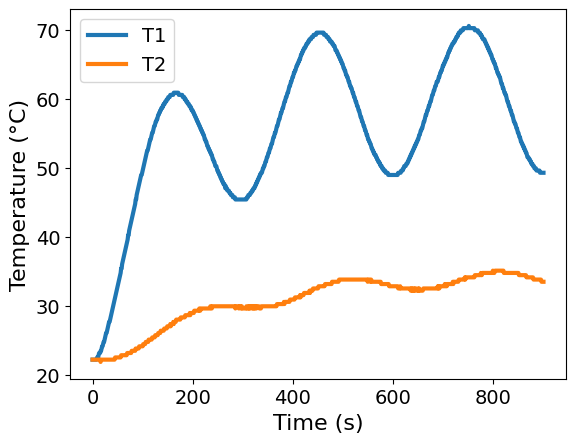

In [4]:
ax = df.plot(x='Time', y=['T1', 'T2'], xlabel='Time (s)', ylabel='Temperature (°C)')

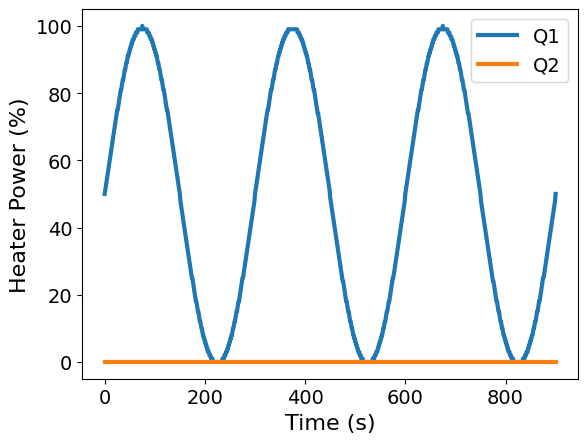

In [5]:
ax = df.plot(x='Time', y=['Q1', 'Q2'], xlabel='Time (s)', ylabel='Heater Power (%)')

We will store the data in an instance of our `TC_Lab_data` dataclass, which converts the numerical data to a  Pandas dataframe

In [6]:
# Here, we will induce a step size of 10 seconds, as to not give too many 
# degrees of freedom for experimental design.
skip = 1
#! Question: Why are we skipping every 10 seconds? For Parmest we did not skip any data
#! so, if we skip data and use the unskipped theta from Parmest, that will be a mismatch. 
# Create the data object considering the new control points every 10 seconds
tc_data = TC_Lab_data(
    name="Sine Wave Test for Heater 1",
    time=df['Time'].values[::skip],
    T1=df['T1'].values[::skip],
    u1=df['Q1'].values[::skip],
    P1=200,
    TS1_data=None,
    T2=df['T2'].values[::skip],
    u2=df['Q2'].values[::skip],
    P2=200,
    TS2_data=None,
    Tamb=df['T1'].values[0],
)

## Calculate the FIM at the already existing experimental data
Since we have one experimental data, we will use the theta value estimated from that experimental data and and compute the FIM using that data.

In [7]:
# Load Pyomo.DoE class
from pyomo.contrib.doe import DesignOfExperiments

from pyomo.environ import SolverFactory

# From the experiment data (Copied from previous notebook)
theta_values = {
    'Ua': 0.0417051733576387,
    'Ub': 0.009440714239773074,
    'inv_CpH': 0.1659093525658045,
    'inv_CpS': 5.8357556063605465,
}

In [8]:
# Create experiment object for design of experiments
doe_experiment = TC_Lab_experiment(
    data=tc_data, theta_initial=theta_values, number_of_states=number_tclab_states
)

# Create the design of experiments object using our experiment instance from above
TC_Lab_DoE = DesignOfExperiments(
    experiment=doe_experiment,
    step=1e-2,
    scale_constant_value=1,
    scale_nominal_param_value=True,
    tee=True,
)

FIM = TC_Lab_DoE.compute_FIM(method='sequential')

Ipopt 3.13.2: linear_solver=ma57
halt_on_ampl_error=yes
max_iter=3000


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for

In [9]:
results_summary(FIM)

======Results Summary======
Four design criteria log10() value:
A-optimality: 7.157639770114507
D-optimality: 11.579675162999582
E-optimality: -6.745084006473853
Modified E-optimality: 13.84872187345891

FIM:
 [[ 1.24815105e+07  5.28632208e+04 -1.54418040e+06  9.38139517e+02]
 [ 5.28632208e+04  1.29239989e+05  3.05602336e+05  1.34973948e+05]
 [-1.54418040e+06  3.05602336e+05  1.62339132e+06  3.48449589e+05]
 [ 9.38139517e+02  1.34973948e+05  3.48449589e+05  1.41914640e+05]]

eigenvalues:
 [1.26970296e+07 1.57328891e+06 1.05737930e+05 1.79852299e-07]

eigenvectors:
 [[ 9.90396330e-01  1.30948423e-01 -4.43578588e-02 -2.90900070e-07]
 [ 7.64920371e-04  2.25444224e-01  6.82615055e-01 -6.95133802e-01]
 [-1.38204326e-01  9.32899556e-01 -3.31741098e-01 -2.33629366e-02]
 [-3.75343966e-03  2.48446838e-01  6.49628286e-01  7.18500640e-01]]


## Optimize two experiments (D-optimality)
We can now optimize two experiments. First we have to create a new instance of `DesignOfExperiments`, and specify the `prior_FIM` (summation of FIMs from already conducted experiment). Since we have only one experiment from the sine test, we will pass that FIM as the `prior_FIM`.

In [18]:
# Create a new experiemnt object for design of experiments, using the same data and theta values as before
# Here, we will induce a step size of 60 seconds, as to not give too many
# degrees of freedom for experimental design.
skip = 60

# Create the data object considering the new control points every 60 seconds
tc_data_2 = TC_Lab_data(
    name="Sine Wave Test for Heater 1",
    time=df['Time'].values[::skip],
    T1=df['T1'].values[::skip],
    u1=df['Q1'].values[::skip],
    P1=200,
    TS1_data=None,
    T2=df['T2'].values[::skip],
    u2=df['Q2'].values[::skip],
    P2=200,
    TS2_data=None,
    Tamb=df['T1'].values[0],
)
# Create experiment object for design of experiments
doe_experiment = TC_Lab_experiment(
    data=tc_data_2, theta_initial=theta_values, number_of_states=number_tclab_states
)

# Create the design of experiments object using our experiment instance from above
TC_Lab_DoE_D = DesignOfExperiments(
    experiment=[doe_experiment, doe_experiment],  # We are optimizing two experiments simultaneously!
    step=1e-2,
    scale_constant_value=1,
    scale_nominal_param_value=True,
    objective_option="determinant",  # Now we specify a type of objective, D-opt = "determinant"
    prior_FIM=FIM,  # We use the prior information from the existing experiment!
    tee=True,
    # use_grey_box_objective=True,
    # grey_box_tee = True,

)

TC_Lab_DoE_D.optimize_experiments()

Ipopt 3.13.2: linear_solver=ma57
halt_on_ampl_error=yes
max_iter=3000


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for

In [19]:
TC_Lab_DoE_D.results

{'problem': {'number_of_param_scenarios': 1,
  'number_of_experiments_per_scenario': 2,
  'used_template_experiment': False,
  'finite_difference_scheme': 'central',
  'finite_difference_step': 0.01,
  'scaled_nominal_parameters': True,
  'prior_fim': [[12481510.526727598,
    52863.220798887225,
    -1544180.3989117544,
    938.139517211268],
   [52863.220798887225,
    129239.98892140543,
    305602.33607060876,
    134973.9482428336],
   [-1544180.3989117544,
    305602.33607060876,
    1623391.3168301436,
    348449.5891414366],
   [938.139517211268,
    134973.9482428336,
    348449.5891414366,
    141914.64003099644]],
  'measurement_error_values': [np.float64(22.2),
   28.967913378429607,
   34.38108237897117,
   38.137474310496025,
   40.422483838448024,
   42.32625612732088,
   41.87029831016827,
   43.05898401304687,
   43.50488540083896,
   43.62739879712406,
   44.595480228338076,
   44.75849972831341,
   46.52817035250409,
   47.75911135043804,
   48.2767429810758,
   48.7

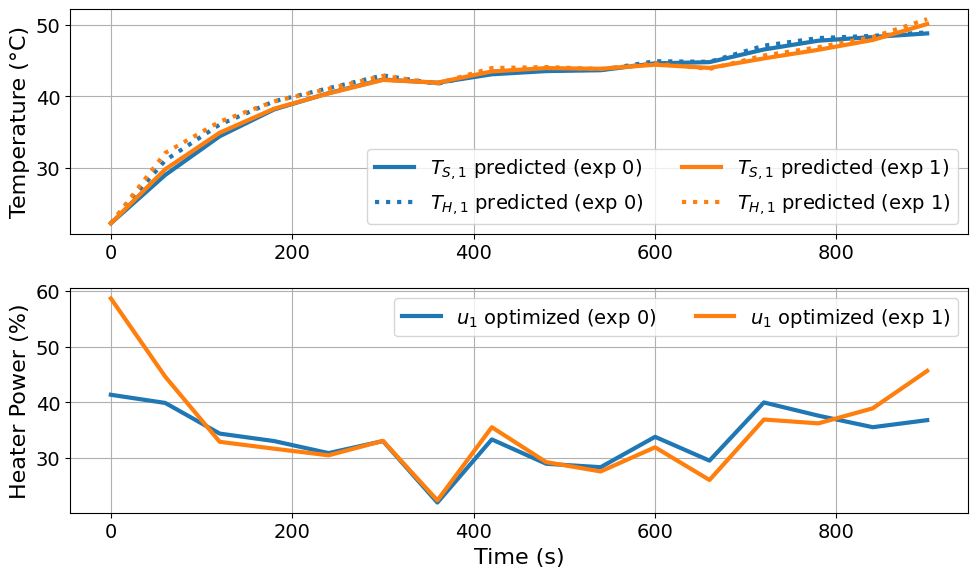

DoE optimize_experiments summary:
parameter scenario: 0
number of experiments: 2
objective: determinant
 


[TC_Lab_data(name='Pyomo DoE results exp 0', time=array([  0.  ,  60.  , 120.01, 180.  , 240.01, 300.01, 360.01, 420.01,
        480.01, 540.01, 600.01, 660.01, 720.  , 780.01, 840.01, 900.01]), T1=array([22.2       , 31.01530816, 36.01837389, 39.27402835, 41.11361813,
        42.90217565, 41.73236427, 43.41857918, 43.63977722, 43.66446093,
        44.88833931, 44.80781556, 47.06361136, 48.13142732, 48.43333427,
        48.93016091]), u1=array([41.3481675 , 39.88137308, 34.37576222, 33.03224983, 30.87426152,
        33.03534239, 21.99779171, 33.32999338, 28.95579284, 28.34251204,
        33.79358208, 29.52087318, 39.96914441, 37.59548392, 35.52541405,
        36.7898755 ]), P1=200, TS1_data=array([22.2       , 28.96791338, 34.38108238, 38.13747431, 40.42248384,
        42.32625613, 41.87029831, 43.05898401, 43.5048854 , 43.6273988 ,
        44.59548023, 44.75849973, 46.52817035, 47.75911135, 48.27674298,
        48.77840167]), T2=None, u2=None, P2=<pyomo.core.base.param.ScalarParam obj

In [20]:
extract_plot_results(None, TC_Lab_DoE_D)

## Optimize two experiments (A-optimality)

In [13]:
# Create a new experiemnt object for design of experiments, using the same data and theta values as before
# Here, we will induce a step size of 60 seconds, as to not give too many
# degrees of freedom for experimental design.
skip = 60

# Create the data object considering the new control points every 60 seconds
tc_data_2 = TC_Lab_data(
    name="Sine Wave Test for Heater 1",
    time=df['Time'].values[::skip],
    T1=df['T1'].values[::skip],
    u1=df['Q1'].values[::skip],
    P1=200,
    TS1_data=None,
    T2=df['T2'].values[::skip],
    u2=df['Q2'].values[::skip],
    P2=200,
    TS2_data=None,
    Tamb=df['T1'].values[0],
)
# Create experiment object for design of experiments
doe_experiment = TC_Lab_experiment(
    data=tc_data_2, theta_initial=theta_values, number_of_states=number_tclab_states
)

# Create the design of experiments object using our experiment instance from above
TC_Lab_DoE_A = DesignOfExperiments(
    experiment=[
        doe_experiment,
        doe_experiment,
        doe_experiment,
    ],  # We are optimizing two experiments simultaneously!
    step=1e-2,
    scale_constant_value=1,
    scale_nominal_param_value=True,
    objective_option="determinant",  # Now we specify a type of objective, D-opt = "determinant"
    prior_FIM=FIM,  # We use the prior information from the existing experiment!
    tee=True,
)

TC_Lab_DoE_A.optimize_experiments()

Ipopt 3.13.2: linear_solver=ma57
halt_on_ampl_error=yes
max_iter=3000


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for

In [14]:
TC_Lab_DoE_A.results

{'problem': {'number_of_param_scenarios': 1,
  'number_of_experiments_per_scenario': 3,
  'used_template_experiment': False,
  'finite_difference_scheme': 'central',
  'finite_difference_step': 0.01,
  'scaled_nominal_parameters': True,
  'prior_fim': [[12481510.526727598,
    52863.220798887225,
    -1544180.3989117544,
    938.139517211268],
   [52863.220798887225,
    129239.98892140543,
    305602.33607060876,
    134973.9482428336],
   [-1544180.3989117544,
    305602.33607060876,
    1623391.3168301436,
    348449.5891414366],
   [938.139517211268,
    134973.9482428336,
    348449.5891414366,
    141914.64003099644]],
  'measurement_error_values': [np.float64(22.2),
   31.53100607422045,
   39.19171809770364,
   44.144136761018856,
   47.083354919803,
   48.741062723711906,
   49.62901367780128,
   50.06895090691579,
   50.25421879743017,
   50.30145718108985,
   50.2880931612306,
   50.27747142850049,
   50.34221962808443,
   50.5877060014344,
   51.18157344435526,
   52.356209